In [20]:
import pandas as pd

In [21]:
csv = pd.read_csv('./reports/report.csv')
df = pd.DataFrame(csv)


In [22]:
df.head()

,Unnamed: 0,Autoencoder,State Detector (Resnet18),Health Assessment (ResNet34),Hybrid,Classic,True
0,0,Not Fall,Fall,Hard Fall,Hard Fall,Hard Fall,Controlled Fall
1,1,Fall,Fall,Controlled Fall,Hard Fall,Hard Fall,Controlled Fall
2,2,Fall,Fall,Controlled Fall,Controlled Fall,Controlled Fall,Controlled Fall
3,3,Fall,Fall,Hard Fall,Hard Fall,Hard Fall,Controlled Fall
4,4,Not Fall,Not Fall,Not Fall,Not Fall,Not Fall,Not Fall


In [23]:
df.tail()

,Unnamed: 0,Autoencoder,State Detector (Resnet18),Health Assessment (ResNet34),Hybrid,Classic,True
403,403,Fall,Fall,SlipTrip,SlipTrip,SlipTrip,SlipTrip
404,404,Not Fall,Not Fall,Not Fall,Not Fall,Not Fall,Not Fall
405,405,Not Fall,Not Fall,Not Fall,Not Fall,Not Fall,Not Fall
406,406,Not Fall,Not Fall,Not Fall,Not Fall,Not Fall,Not Fall
407,407,Not Fall,Not Fall,Not Fall,Not Fall,Not Fall,Not Fall


In [24]:
df

,Unnamed: 0,Autoencoder,State Detector (Resnet18),Health Assessment (ResNet34),Hybrid,Classic,True
0,0,Not Fall,Fall,Hard Fall,Hard Fall,Hard Fall,Controlled Fall
1,1,Fall,Fall,Controlled Fall,Hard Fall,Hard Fall,Controlled Fall
2,2,Fall,Fall,Controlled Fall,Controlled Fall,Controlled Fall,Controlled Fall
3,3,Fall,Fall,Hard Fall,Hard Fall,Hard Fall,Controlled Fall
4,4,Not Fall,Not Fall,Not Fall,Not Fall,Not Fall,Not Fall
...,...,...,...,...,...,...,...
403,403,Fall,Fall,SlipTrip,SlipTrip,SlipTrip,SlipTrip
404,404,Not Fall,Not Fall,Not Fall,Not Fall,Not Fall,Not Fall
405,405,Not Fall,Not Fall,Not Fall,Not Fall,Not Fall,Not Fall
406,406,Not Fall,Not Fall,Not Fall,Not Fall,Not Fall,Not Fall


In [25]:
df[(df["Autoencoder"] == "Fall") & (df["True"] != "Not Fall")].count()

Unnamed: 0                      167
Autoencoder                     167
State Detector (Resnet18)       167
Health Assessment (ResNet34)    167
Hybrid                          167
Classic                         167
True                            167
dtype: int64

In [26]:
df[(df["Autoencoder"] == "Fall") & (df["True"] == "Not Fall")].count()


Unnamed: 0                      56
Autoencoder                     56
State Detector (Resnet18)       56
Health Assessment (ResNet34)    56
Hybrid                          56
Classic                         56
True                            56
dtype: int64

In [27]:
df[(df["Autoencoder"] == "Not Fall") & (df["True"] != "Not Fall")].count()

Unnamed: 0                      37
Autoencoder                     37
State Detector (Resnet18)       37
Health Assessment (ResNet34)    37
Hybrid                          37
Classic                         37
True                            37
dtype: int64

In [28]:
df[(df["State Detector (Resnet18)"] == "Fall") & (df["True"] == "Not Fall")].count()

Unnamed: 0                      2
Autoencoder                     2
State Detector (Resnet18)       2
Health Assessment (ResNet34)    2
Hybrid                          2
Classic                         2
True                            2
dtype: int64

In [29]:
df[(df["State Detector (Resnet18)"] == "Not Fall") & (df["True"] != "Not Fall")].count()

Unnamed: 0                      4
Autoencoder                     4
State Detector (Resnet18)       4
Health Assessment (ResNet34)    4
Hybrid                          4
Classic                         4
True                            4
dtype: int64

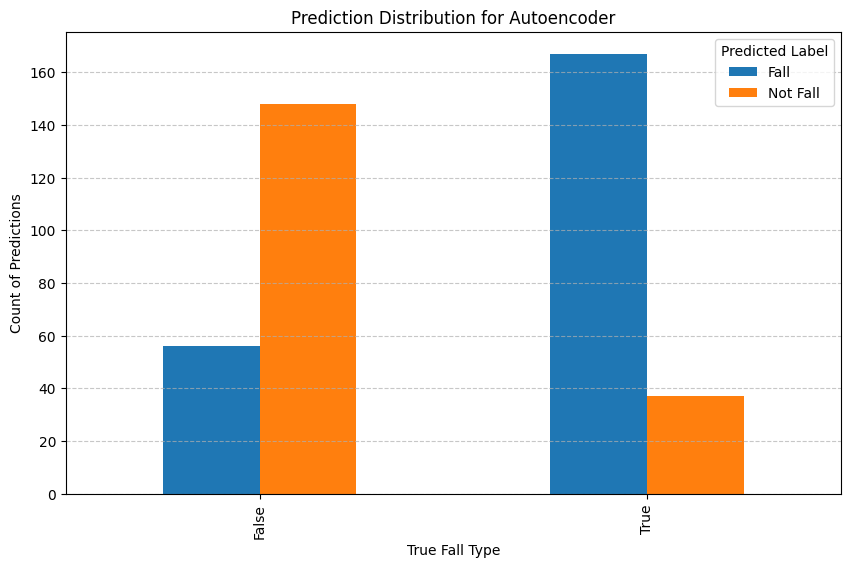

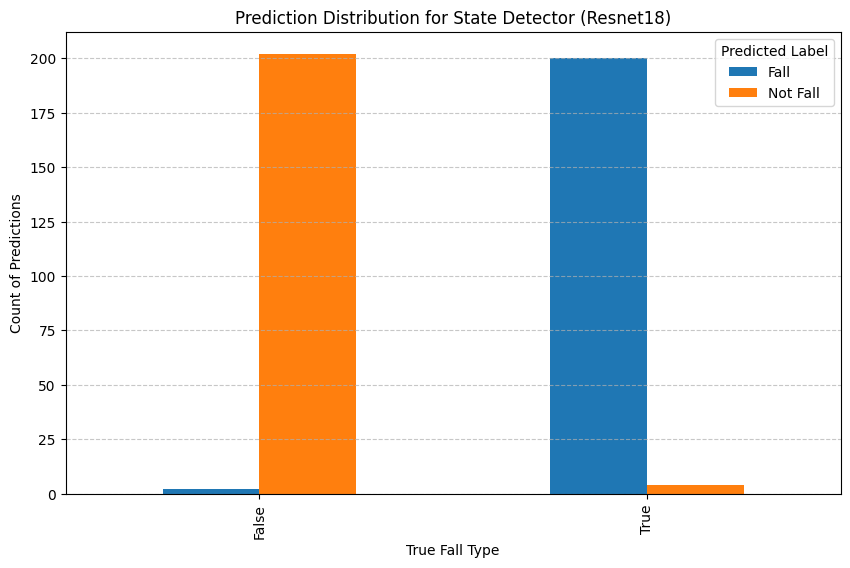

In [30]:
import matplotlib.pyplot as plt

models = ["Autoencoder", "State Detector (Resnet18)"]

for model in models:
    counts = []
    labels = []

    # Build a table of how model predictions distribute for each true label
    pivot = pd.crosstab(df["True"] != "Not Fall", df[model])

    # Plot
    pivot.plot(kind="bar", figsize=(10,6))
    plt.title(f"Prediction Distribution for {model}")
    plt.xlabel("True Fall Type")
    plt.ylabel("Count of Predictions")
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.legend(title="Predicted Label")
    plt.show()

# Prepare to only keep the rows the the state and autoencoder was correct
- This will ensure that the other predicitons is predicting a fall, when there accutally was a fall

In [31]:
df = df[df["True"] != "Not Fall"]

### Find out if all cases where both the ae and the sd belived it was not fall even if it was

In [32]:
df[(df["Autoencoder"] == "Not Fall") & (df["State Detector (Resnet18)"] == "Not Fall")]

,Unnamed: 0,Autoencoder,State Detector (Resnet18),Health Assessment (ResNet34),Hybrid,Classic,True


In [33]:
amount_of_fall = len(df)

In [34]:
df[(df["Health Assessment (ResNet34)"] == "Hard Fall") & (df["True"] == "Hard Fall")]

,Unnamed: 0,Autoencoder,State Detector (Resnet18),Health Assessment (ResNet34),Hybrid,Classic,True
88,88,Fall,Fall,Hard Fall,Hard Fall,Hard Fall,Hard Fall
89,89,Fall,Fall,Hard Fall,Hard Fall,Hard Fall,Hard Fall
90,90,Fall,Fall,Hard Fall,Hard Fall,Hard Fall,Hard Fall
91,91,Fall,Fall,Hard Fall,Hard Fall,Hard Fall,Hard Fall
96,96,Fall,Fall,Hard Fall,Hard Fall,Hard Fall,Hard Fall
...,...,...,...,...,...,...,...
235,235,Not Fall,Fall,Hard Fall,Hard Fall,SlipTrip,Hard Fall
240,240,Fall,Fall,Hard Fall,Hard Fall,Hard Fall,Hard Fall
241,241,Fall,Fall,Hard Fall,Hard Fall,Hard Fall,Hard Fall
242,242,Fall,Fall,Hard Fall,Controlled Fall,Hard Fall,Hard Fall


In [35]:
df[(df["Health Assessment (ResNet34)"] == "SlipTrip") & (df["True"] == "SlipTrip")]


,Unnamed: 0,Autoencoder,State Detector (Resnet18),Health Assessment (ResNet34),Hybrid,Classic,True
248,248,Fall,Fall,SlipTrip,Hard Fall,Hard Fall,SlipTrip
249,249,Fall,Fall,SlipTrip,SlipTrip,SlipTrip,SlipTrip
250,250,Fall,Fall,SlipTrip,SlipTrip,SlipTrip,SlipTrip
251,251,Fall,Fall,SlipTrip,Hard Fall,Hard Fall,SlipTrip
256,256,Fall,Fall,SlipTrip,Hard Fall,Hard Fall,SlipTrip
...,...,...,...,...,...,...,...
395,395,Fall,Fall,SlipTrip,SlipTrip,SlipTrip,SlipTrip
400,400,Fall,Fall,SlipTrip,Hard Fall,Hard Fall,SlipTrip
401,401,Fall,Fall,SlipTrip,Hard Fall,SlipTrip,SlipTrip
402,402,Fall,Fall,SlipTrip,SlipTrip,SlipTrip,SlipTrip


In [36]:
df[(df["Health Assessment (ResNet34)"] == "Controlled Fall") & (df["True"] == "Controlled Fall")]


,Unnamed: 0,Autoencoder,State Detector (Resnet18),Health Assessment (ResNet34),Hybrid,Classic,True
1,1,Fall,Fall,Controlled Fall,Hard Fall,Hard Fall,Controlled Fall
2,2,Fall,Fall,Controlled Fall,Controlled Fall,Controlled Fall,Controlled Fall
17,17,Fall,Fall,Controlled Fall,Hard Fall,SlipTrip,Controlled Fall
18,18,Not Fall,Fall,Controlled Fall,Controlled Fall,Controlled Fall,Controlled Fall
19,19,Not Fall,Fall,Controlled Fall,Hard Fall,Controlled Fall,Controlled Fall
34,34,Fall,Fall,Controlled Fall,Controlled Fall,Controlled Fall,Controlled Fall
49,49,Fall,Fall,Controlled Fall,Controlled Fall,Controlled Fall,Controlled Fall
50,50,Fall,Fall,Controlled Fall,Controlled Fall,Controlled Fall,Controlled Fall
57,57,Fall,Fall,Controlled Fall,Hard Fall,Hard Fall,Controlled Fall
58,58,Fall,Fall,Controlled Fall,Controlled Fall,Controlled Fall,Controlled Fall


In [37]:
df[(df["Health Assessment (ResNet34)"] == "Hard Fall") & (df["True"] != "Hard Fall")].count()

Unnamed: 0                      43
Autoencoder                     43
State Detector (Resnet18)       43
Health Assessment (ResNet34)    43
Hybrid                          43
Classic                         43
True                            43
dtype: int64

In [38]:
df[(df["Health Assessment (ResNet34)"] == "SlipTrip") & (df["True"] != "SlipTrip")].count()


Unnamed: 0                      5
Autoencoder                     5
State Detector (Resnet18)       5
Health Assessment (ResNet34)    5
Hybrid                          5
Classic                         5
True                            5
dtype: int64

In [39]:
df[(df["Health Assessment (ResNet34)"] != df["True"])].count()

Unnamed: 0                      53
Autoencoder                     53
State Detector (Resnet18)       53
Health Assessment (ResNet34)    53
Hybrid                          53
Classic                         53
True                            53
dtype: int64

In [40]:
df[(df["Hybrid"] != df["True"])].count()


Unnamed: 0                      64
Autoencoder                     64
State Detector (Resnet18)       64
Health Assessment (ResNet34)    64
Hybrid                          64
Classic                         64
True                            64
dtype: int64

In [41]:
df[(df["Classic"] != df["True"])].count()


Unnamed: 0                      67
Autoencoder                     67
State Detector (Resnet18)       67
Health Assessment (ResNet34)    67
Hybrid                          67
Classic                         67
True                            67
dtype: int64

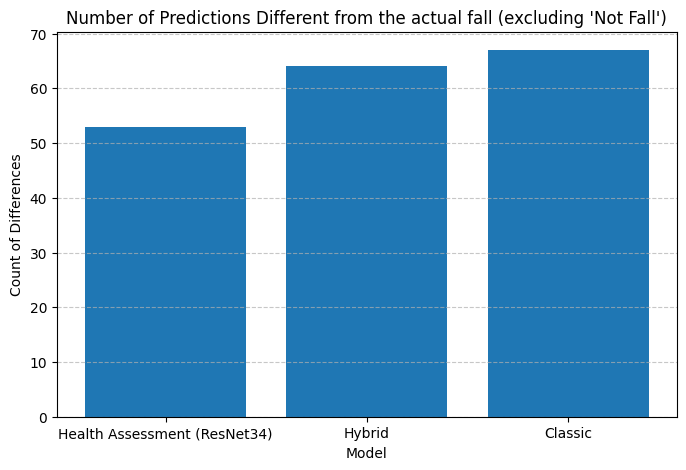

In [43]:
comparison_columns = ["Health Assessment (ResNet34)", "Hybrid", "Classic"]
differences = {col: (df[col] != df["True"]).sum() for col in comparison_columns}

# Convert to DataFrame for plotting
diff_df = pd.DataFrame(list(differences.items()), columns=["Model", "Differences"])

# Plot the results
plt.figure(figsize=(8, 5))
plt.bar(diff_df["Model"], diff_df["Differences"])
plt.title("Number of Predictions Different from the actual fall (excluding 'Not Fall')")
plt.xlabel("Model")
plt.ylabel("Count of Differences")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

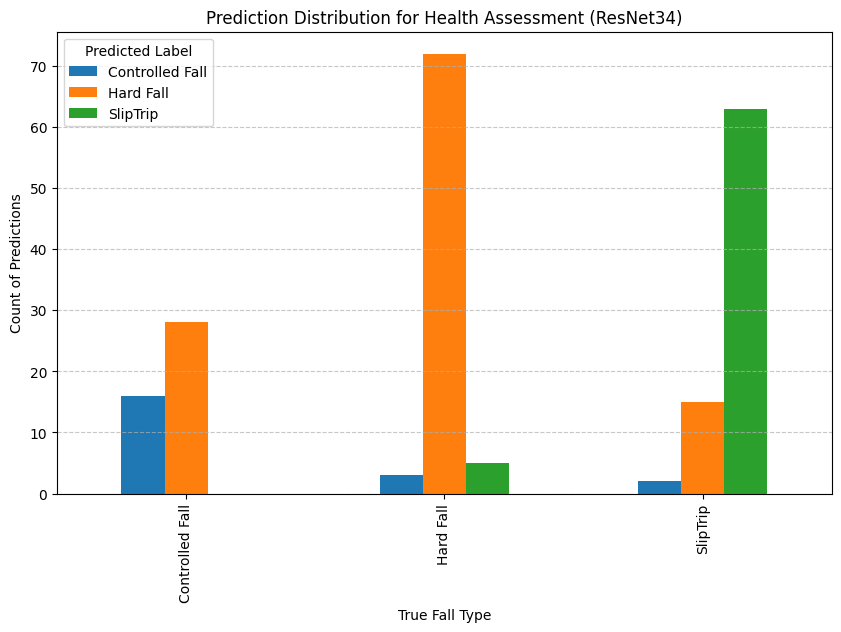

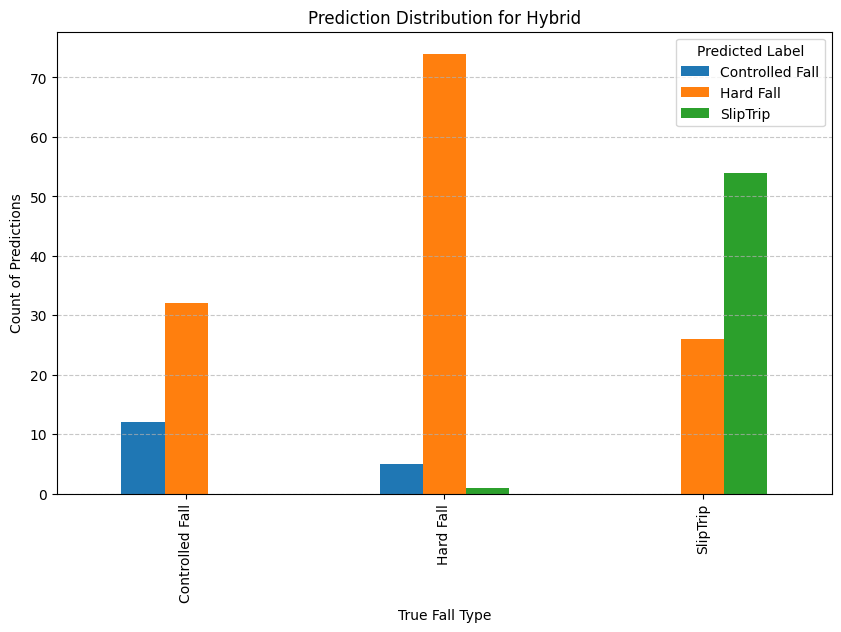

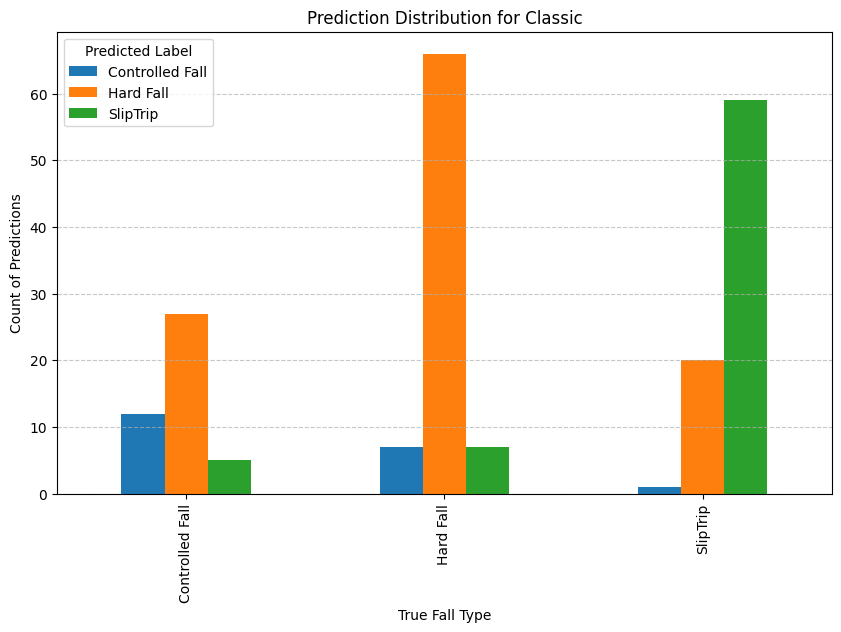

In [44]:
models = ["Health Assessment (ResNet34)", "Hybrid", "Classic"]
true_classes = df["True"].unique()

# For each model, count predictions for each true class
for model in models:
    counts = []
    labels = []

    # Build a table of how model predictions distribute for each true label
    pivot = pd.crosstab(df["True"], df[model])

    # Plot
    pivot.plot(kind="bar", figsize=(10,6))
    plt.title(f"Prediction Distribution for {model}")
    plt.xlabel("True Fall Type")
    plt.ylabel("Count of Predictions")
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.legend(title="Predicted Label")
    plt.show()